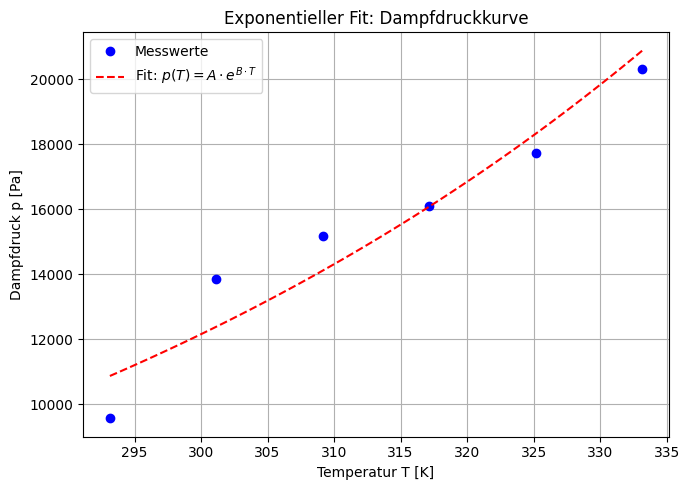

=== Exponentieller Fit ===
p(T) = A · e^(B·T)
A = 9.1265e+01
B = 1.6307e-02


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Daten einlesen
col_C = pd.read_excel("Exp7_Dampfdruckkurve_p(T)_Template_2025.xlsx",
                      engine="openpyxl", usecols="W, X", skiprows=22, nrows=12)
col_C.columns = ["T", "p"]
col_C = col_C.dropna()

# Logarithmieren
col_C["ln(p)"] = np.log(col_C["p"])

# X und Y
x = col_C["T"].values
y_ln = col_C["ln(p)"].values

# Lineare Regression von ln(p) gegen T
reg = linregress(x, y_ln)
slope = reg.slope
intercept = reg.intercept

# Fit-Kurve berechnen
x_fit = np.linspace(min(x), max(x), 100)
y_fit = np.exp(slope * x_fit + intercept)  # zurücktransformiert auf p(T)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(x, col_C["p"], 'o', label='Messwerte', color='blue')
plt.plot(x_fit, y_fit, '--', label=fr'Fit: $p(T) = A \cdot e^{{B \cdot T}}$', color='red')

plt.xlabel("Temperatur T [K]")
plt.ylabel("Dampfdruck p [Pa]")
plt.title("Exponentieller Fit: Dampfdruckkurve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Fit-Parameter berechnen
A = np.exp(intercept)
B = slope

print("=== Exponentieller Fit ===")
print(f"p(T) = A · e^(B·T)")
print(f"A = {A:.4e}")
print(f"B = {B:.4e}")

Fitted value for H: -6752.97 +/- 4867.90
Fitted value for T_SD: 3346216630.22 +/- 18144377916792316.00


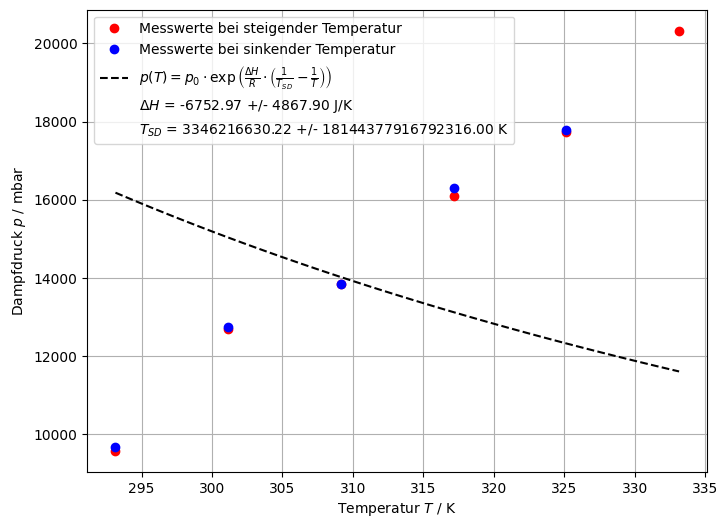

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import linregress

# Daten einlesen
col_C = pd.read_excel("Exp7_Dampfdruckkurve_p(T)_Template_2025.xlsx",
                      engine="openpyxl", usecols="W, X", skiprows=22, nrows=12)
col_C.columns = ["T", "p"]
col_C = col_C.dropna()

# Define the function based on the provided formula
def fit_function(T, H, T_SD):
  return 1013 * np.exp(H / 8.314 * (1/T_SD - 1/T))

# Perform the curve fitting
# Use the whole range of T and p_kor for fitting
T = col_C["T"]
p_kor = col_C["p"]  # oder wie auch immer du den korrigierten Druck nennst

# Provide initial guess for H and T_SD.
# These values can influence the fitting process.
# Let's start with some plausible values based on the data range.
# T_SD could be around the maximum temperature in the data, and H is harder to guess.
# Let's try H around 40000 and T_SD around 330
initial_guess = [30000, 350]  # statt 40000, 330

params, covariance = curve_fit(fit_function, col_C["T"], col_C["p"], p0=initial_guess)

# Extract the fitted parameters
H_fit, T_SD_fit = params

# Calculate the standard deviations (errors) from the covariance matrix
# The diagonal elements of the covariance matrix are the variances of the parameters
perr = np.sqrt(np.diag(covariance))
H_error, T_SD_error = perr

print(f"Fitted value for H: {H_fit:.2f} +/- {H_error:.2f}")
print(f"Fitted value for T_SD: {T_SD_fit:.2f} +/- {T_SD_error:.2f}")

# Generate points for the fitted curve
T_fit = np.linspace(col_C["T"].min(), col_C["T"].max(), 100)
p_fit = fit_function(T_fit, H_fit, T_SD_fit)

# Plot the original data and the fitted curve
plt.figure(figsize=(8, 6))
plt.plot(col_C["T"][:6], col_C["p"][:6], marker="o", linestyle="", color='red', label='Messwerte bei steigender Temperatur')
plt.plot(col_C["T"][6:], col_C["p"][6:], marker="o", linestyle="", color='blue', label='Messwerte bei sinkender Temperatur')
plt.plot(T_fit, p_fit, linestyle='--', color='black', label=r"$p(T) = p_0 \cdot \exp \left(\frac{\Delta H}{R} \cdot \left(\frac{1}{T_{SD}} - \frac{1}{T}\right)\right)$")

plt.plot([], []," ", label=fr"$\Delta H$ = {H_fit:.2f} +/- {H_error:.2f} J/K")
plt.plot([], []," ", label=fr"$T_{{SD}}$ = {T_SD_fit:.2f} +/- {T_SD_error:.2f} K")

plt.xlabel("Temperatur $T$ / K")
plt.ylabel("Dampfdruck $p$ / mbar")
plt.grid(True)
plt.legend()
plt.show()

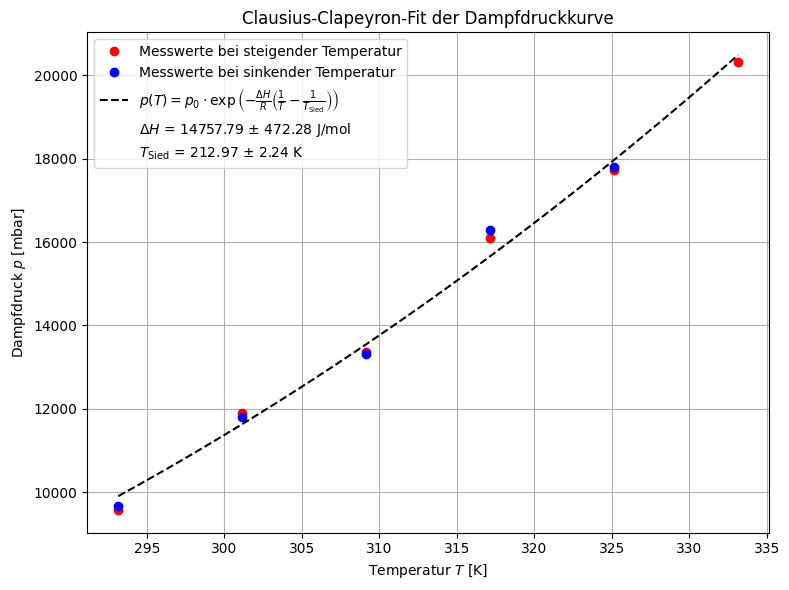

=== Fit-Ergebnisse ===
ΔH_verd = 14757.79 ± 472.28 J/mol
T_sied = 212.97 ± 2.24 K


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Daten einlesen
# ===============================
col_C = pd.read_excel("Exp7_Dampfdruckkurve_p(T)_Template_2025.xlsx",
                      engine="openpyxl", usecols="W, X", skiprows=22, nrows=12)
col_C.columns = ["T", "p"]
col_C = col_C.dropna()

# ===============================
# Clausius-Clapeyron-Funktion
# ===============================
def fit_function(T, H, T_SD):
    R = 8.314
    exponent = -H / R * (1/T - 1/T_SD)
    exponent = np.clip(exponent, -700, 700)  # Begrenzung gegen Overflow
    return 1013 * np.exp(exponent)

# ===============================
# Anfangsschätzungen & Fit
# ===============================
T = col_C["T"].values
p_kor = col_C["p"].values

initial_guess = [40000, 370]  # H in J/mol, T_SD in K

params, covariance = curve_fit(fit_function, T, p_kor, p0=initial_guess)

H_fit, T_SD_fit = params
H_err, T_SD_err = np.sqrt(np.diag(covariance))

# ===============================
# Fit-Kurve berechnen
# ===============================
T_fit = np.linspace(T.min(), T.max(), 200)
p_fit = fit_function(T_fit, H_fit, T_SD_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(8, 6))

# Datenpunkte einfärben
plt.plot(T[:6], p_kor[:6], 'o', color='red', label='Messwerte bei steigender Temperatur')
plt.plot(T[6:], p_kor[6:], 'o', color='blue', label='Messwerte bei sinkender Temperatur')

# Fit-Kurve
plt.plot(T_fit, p_fit, '--', color='black',
         label=r"$p(T) = p_0 \cdot \exp \left(-\frac{\Delta H}{R} \left(\frac{1}{T} - \frac{1}{T_{\mathrm{Sied}}} \right) \right)$")

# Ergebnisbeschriftung
plt.plot([], [], " ", label=fr"$\Delta H$ = {H_fit:.2f} ± {H_err:.2f} J/mol")
plt.plot([], [], " ", label=fr"$T_{{\mathrm{{Sied}}}}$ = {T_SD_fit:.2f} ± {T_SD_err:.2f} K")

plt.xlabel("Temperatur $T$ [K]")
plt.ylabel("Dampfdruck $p$ [mbar]")
plt.title("Clausius-Clapeyron-Fit der Dampfdruckkurve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Konsole-Ausgabe
# ===============================
print("=== Fit-Ergebnisse ===")
print(f"ΔH_verd = {H_fit:.2f} ± {H_err:.2f} J/mol")
print(f"T_sied = {T_SD_fit:.2f} ± {T_SD_err:.2f} K")

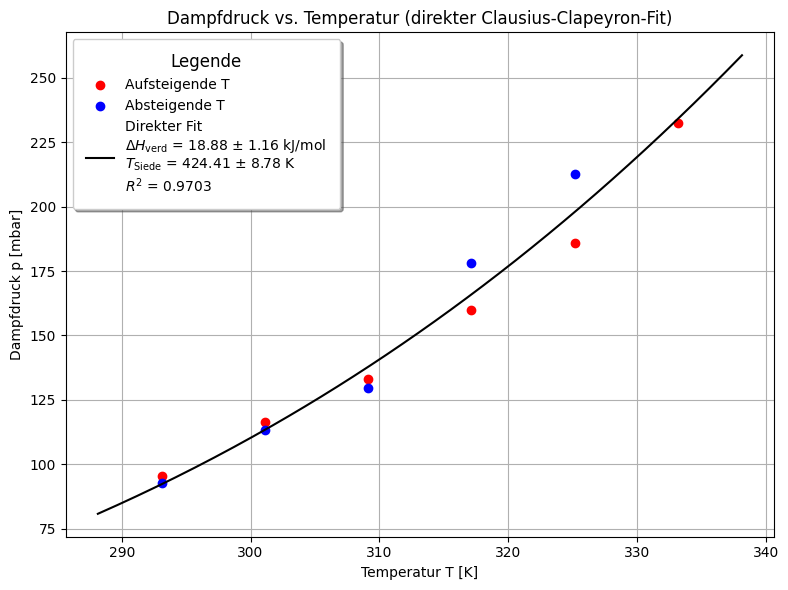


Formel: p(T) = p0 * exp[ (ΔH_v / R) * (1/T_siede - 1/T) ]
ΔH_verd = 18877.55 ± 1155.95 J/mol
T_Siede = 424.41 ± 8.78 K
R² = 0.9703


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Messdaten
T = np.array([293.15, 301.15, 309.15, 317.15, 325.15, 333.15, 325.15, 317.15, 309.15, 301.15, 293.15])
p = np.array([95.42, 116.32, 132.91, 159.91, 185.82, 232.36, 212.54, 178.29, 129.57, 113.35, 92.5])

# Konstanten
p0 = 1013  # mbar
R = 8.314462618  # J/mol·K

# Define the function based on the provided formula
def fit_function(T, H, T_SD):
  return 1013 * np.exp(H / 8.314 * (1/T_SD - 1/T))


# Nichtlinearer Fit
initial_guess = [40000, 373.15]
params, cov = curve_fit(pressure_model, T, p, p0=initial_guess)
delta_H_v, T_siede = params
delta_H_v_err, T_siede_err = np.sqrt(np.diag(cov))

# R² berechnen
residuals = p - pressure_model(T, *params)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((p - np.mean(p))**2)
r_squared = 1 - (ss_res / ss_tot)

# Fit-Kurve
T_fit = np.linspace(min(T) - 5, max(T) + 5, 200)
p_fit = pressure_model(T_fit, *params)

# Aufspalten der Messpunkte in auf- und absteigende Temperatur
T_up = T[:6]
p_up = p[:6]
T_down = T[6:]
p_down = p[6:]

# Fit-Label mit Formelparametern und R²
fit_label = (
    f'Direkter Fit\n'
    r'$\Delta H_\mathrm{{verd}}$'
    f' = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol\n'
    r'$T_\mathrm{{Siede}}$'
    f' = {T_siede:.2f} ± {T_siede_err:.2f} K\n'
    r'$R^2$'
    f' = {r_squared:.4f}'
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(T_up, p_up, color='red', label='Aufsteigende T')
plt.scatter(T_down, p_down, color='blue', label='Absteigende T')
plt.plot(T_fit, p_fit, color='black', label=fit_label)

plt.xlabel('Temperatur T [K]')
plt.ylabel('Dampfdruck p [mbar]')
plt.title('Dampfdruck vs. Temperatur (direkter Clausius-Clapeyron-Fit)')
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True, borderpad=1, ncol=1,
   title='Legende', title_fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Fit-Ergebnisse auch in Konsole ausgeben
print(f"\nFormel: p(T) = p0 * exp[ (ΔH_v / R) * (1/T_siede - 1/T) ]")
print(f"ΔH_verd = {delta_H_v:.2f} ± {delta_H_v_err:.2f} J/mol")
print(f"T_Siede = {T_siede:.2f} ± {T_siede_err:.2f} K")
print(f"R² = {r_squared:.4f}")

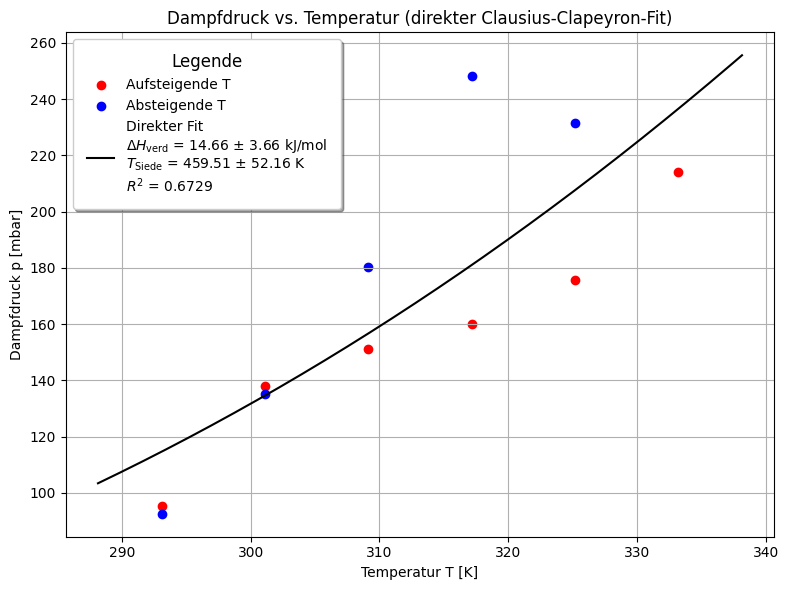


Formel: p(T) = p0 * exp[ (ΔH_v / R) * (1/T_siede - 1/T) ]
ΔH_verd = 14657.35 ± 3656.71 J/mol
T_Siede = 459.51 ± 52.16 K
R² = 0.6729


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Messdaten
T = np.array([293.15, 301.15, 309.15, 317.15, 325.15, 333.15, 325.15, 317.15, 309.15, 301.15, 293.15])
p = np.array([95.42, 137.92, 151.11, 159.91, 175.82, 214.06, 231.54, 248.29, 180.27, 135.15, 92.6])

# Konstanten
p0 = 1013  # mbar
R = 8.314462618  # J/mol·K

# Define the function based on the provided formula
# Definiere die Fit-Funktion (mit korrektem Namen!)
def pressure_model(T, H, T_SD):
    return 1013 * np.exp(H / 8.314 * (1/T_SD - 1/T))


# Nichtlinearer Fit
initial_guess = [40000, 373.15]
params, cov = curve_fit(pressure_model, T, p, p0=initial_guess)
delta_H_v, T_siede = params
delta_H_v_err, T_siede_err = np.sqrt(np.diag(cov))

# R² berechnen
residuals = p - pressure_model(T, *params)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((p - np.mean(p))**2)
r_squared = 1 - (ss_res / ss_tot)

# Fit-Kurve
T_fit = np.linspace(min(T) - 5, max(T) + 5, 200)
p_fit = pressure_model(T_fit, *params)

# Aufspalten der Messpunkte in auf- und absteigende Temperatur
T_up = T[:6]
p_up = p[:6]
T_down = T[6:]
p_down = p[6:]

# Fit-Label mit Formelparametern und R²
fit_label = (
    f'Direkter Fit\n'
    r'$\Delta H_\mathrm{{verd}}$'
    f' = {delta_H_v/1000:.2f} ± {delta_H_v_err/1000:.2f} kJ/mol\n'
    r'$T_\mathrm{{Siede}}$'
    f' = {T_siede:.2f} ± {T_siede_err:.2f} K\n'
    r'$R^2$'
    f' = {r_squared:.4f}'
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(T_up, p_up, color='red', label='Aufsteigende T')
plt.scatter(T_down, p_down, color='blue', label='Absteigende T')
plt.plot(T_fit, p_fit, color='black', label=fit_label)

plt.xlabel('Temperatur T [K]')
plt.ylabel('Dampfdruck p [mbar]')
plt.title('Dampfdruck vs. Temperatur (direkter Clausius-Clapeyron-Fit)')
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True, borderpad=1, ncol=1,
   title='Legende', title_fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Fit-Ergebnisse auch in Konsole ausgeben
print(f"\nFormel: p(T) = p0 * exp[ (ΔH_v / R) * (1/T_siede - 1/T) ]")
print(f"ΔH_verd = {delta_H_v:.2f} ± {delta_H_v_err:.2f} J/mol")
print(f"T_Siede = {T_siede:.2f} ± {T_siede_err:.2f} K")
print(f"R² = {r_squared:.4f}")